# The Superfan Revenue Engine — RevOps for Independent Artists

**The thesis:** streams pay an independent artist roughly €0.003 each. A superfan — someone who buys the vinyl, the shirt, the gig ticket — is worth €30–300 per year. Yet almost all indie marketing chases streams, the lowest-value action a fan can take, because streams are what dashboards show.

This project treats a fan base the way a B2B company treats a sales pipeline:

| Sales world | Music world |
|---|---|
| Lead | Casual streamer |
| MQL | Saved tracks + follows socials |
| SQL | Mailing list, attends shows |
| Closed-won account | Paying supporter (merch, vinyl, tickets) |
| Territory planning | Tour routing |

We score every fan for superfan conversion (with SHAP explanations), compute **Expected Fan Value**, and feed the geography into a **demand-arbitrage tour optimizer**.

> Data is fully synthetic (`src/generate_data.py`) — a documented latent model, no real artists or fans.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import TARGET, REVENUE

fans = pd.read_csv("../data/fans.csv")
print(f"{len(fans):,} fans | {fans[TARGET].mean():.1%} became paying supporters | "
      f"EUR {fans[REVENUE].sum():,.0f} supporter revenue over 12 months")
fans.head(3)

30,000 fans | 12.9% became paying supporters | EUR 133,458 supporter revenue over 12 months


,fan_id,city,age_band,discovery_channel,months_since_discovery,monthly_streams,catalog_depth_pct,skip_rate,playlist_adds,saves_library,follows_socials,social_engagements_90d,on_mailing_list,email_open_rate,attended_show,shared_track,comments_dms,became_supporter,supporter_revenue_12m
0,F200000,Tallinn,40-54,Algorithmic radio,4.9,4,6.0,0.561,2,0,0,0,0,0.0,0,0,0,0,0.0
1,F200001,London,30-39,Algorithmic radio,10.6,36,91.0,0.038,7,1,1,9,0,0.0,0,0,2,0,0.0
2,F200002,Madrid,40-54,Another artist's collab,13.2,3,3.0,0.479,0,0,0,0,0,0.0,0,0,0,0,0.0


## 1. The economics that make this worth building

How concentrated is supporter revenue, really?

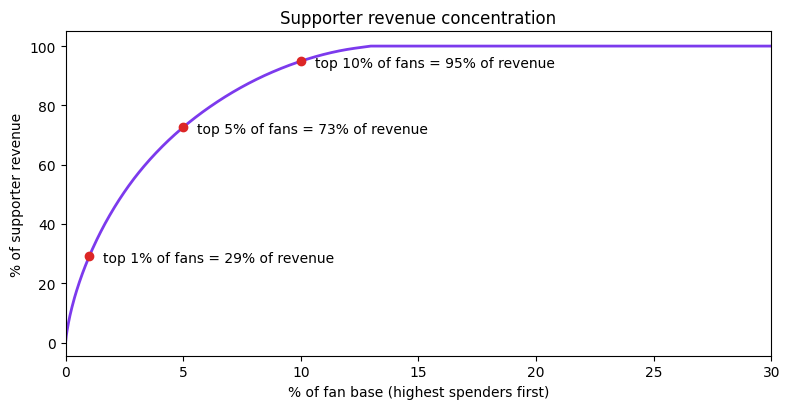

In [2]:
rev = np.sort(fans[REVENUE].to_numpy())[::-1]
cum = np.cumsum(rev) / rev.sum()
pct = np.arange(1, len(rev) + 1) / len(rev)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(pct * 100, cum * 100, color="#7c3aed", lw=2)
for q in (0.01, 0.05, 0.10):
    i = int(len(rev) * q) - 1
    ax.scatter([q * 100], [cum[i] * 100], color="#dc2626", zorder=3)
    ax.annotate(f"top {q:.0%} of fans = {cum[i]:.0%} of revenue",
                (q * 100, cum[i] * 100), textcoords="offset points", xytext=(10, -4))
ax.set_xlabel("% of fan base (highest spenders first)")
ax.set_ylabel("% of supporter revenue")
ax.set_title("Supporter revenue concentration")
ax.set_xlim(0, 30)
plt.tight_layout(); plt.show()

A tiny slice of the fan base carries most of the money. Equivalent stream value makes the point brutally: one €50/year supporter is worth ~16,000 streams. **Finding the next 200 superfans matters more than finding the next 200,000 streams.**

## 2. Not all discovery channels create equal fans

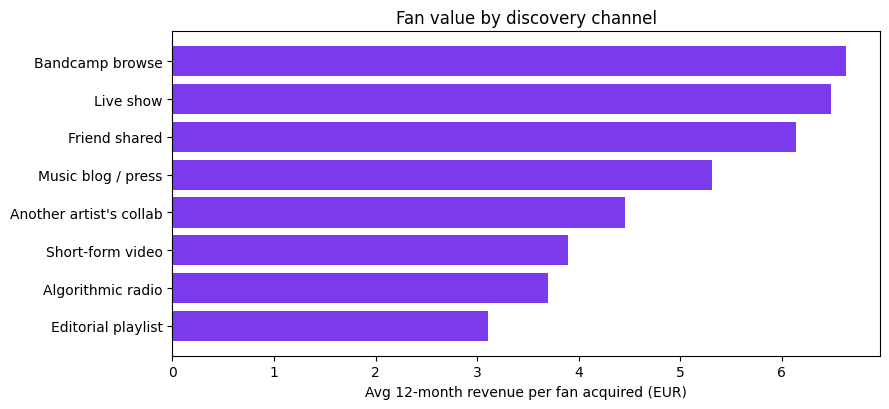

,fans,supporter_rate,rev_per_fan
discovery_channel,,,
Bandcamp browse,1219,0.182,6.635
Live show,2380,0.198,6.483
Friend shared,4815,0.185,6.141
Music blog / press,1459,0.143,5.313
Another artist's collab,2113,0.118,4.454
Short-form video,4264,0.118,3.897
Algorithmic radio,6550,0.101,3.700
Editorial playlist,7200,0.094,3.105


In [3]:
by_ch = fans.groupby("discovery_channel").agg(
    fans=("fan_id", "size"),
    supporter_rate=(TARGET, "mean"),
    rev_per_fan=(REVENUE, "mean"),
).sort_values("rev_per_fan", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(by_ch.index[::-1], by_ch["rev_per_fan"][::-1], color="#7c3aed")
ax.set_xlabel("Avg 12-month revenue per fan acquired (EUR)")
ax.set_title("Fan value by discovery channel")
plt.tight_layout(); plt.show()
by_ch.round(3)

The volume channels (editorial playlists, algorithmic radio) create the *cheapest* fans; live shows, friend-shares, and Bandcamp create the most valuable ones. Editorial placement is fine for reach — but budgeting promo as if all listeners are equal systematically overpays for passive ears.

## 3. The scoring model

`src/train.py` trains an XGBoost classifier for P(supporter) plus a conditional revenue model, giving **Expected Fan Value = P(convert) × E[revenue | convert]**. Holdout metrics:

In [4]:
meta = json.loads(Path("../models/metadata.json").read_text())
pd.Series(meta["metrics"]).to_frame("value")

,value
roc_auc,0.7981
pr_auc,0.4296
baseline_logreg_roc_auc,0.799
base_conversion_rate,0.1295
top_decile_lift,3.81
top_2_deciles_capture_pct,0.5869
revenue_capture_top_10pct,0.375
best_iteration,144
n_train,24000
n_test,6000


Honest notes, as always: a logistic-regression baseline essentially ties XGBoost on this feature set (reported above, not hidden), and AUC ≈ 0.80 is a realistic ceiling for behavior this noisy — anything near 0.99 would mean target leakage.

## 4. What the model rewards (SHAP)

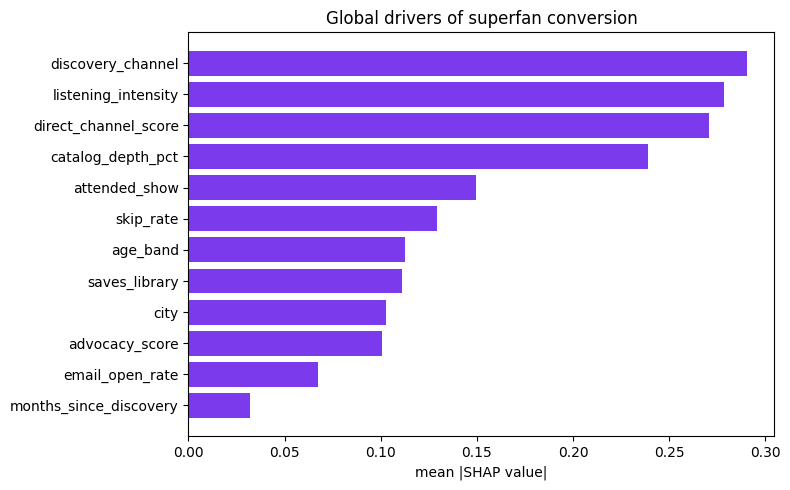

In [5]:
imp = pd.Series(meta["global_shap_importance"]).head(12)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#7c3aed")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Global drivers of superfan conversion")
plt.tight_layout(); plt.show()

The engine independently rediscovers the folk wisdom of DIY music marketing — **owned channels (mailing list) beat rented reach (platform follows)**, listening *depth* beats listening *volume*, live exposure converts — but quantifies it per fan, and the API returns each fan's personal drivers so outreach is targeted, not generic.

## 5. Lift: does ranking fans actually work?

In [6]:
lift = pd.read_csv("../models/lift_table.csv", index_col=0)
capture = pd.DataFrame(meta["revenue_capture"])
print("Top decile of fans converts at "
      f"{meta['metrics']['top_decile_lift']:.1f}x the base rate.")
print(f"Contacting the top 10% by Expected Fan Value reaches "
      f"{meta['metrics']['revenue_capture_top_10pct']:.0%} of all supporter revenue.")
capture

Top decile of fans converts at 3.8x the base rate.
Contacting the top 10% by Expected Fan Value reaches 38% of all supporter revenue.


,top_pct_of_fans,revenue_captured
0,1%,0.039
1,2%,0.076
2,5%,0.204
3,10%,0.375
4,20%,0.563
5,50%,0.835


For an artist (or a small label) with a €300/month promo budget and a few hours a week, this is the whole point: **spend it on the 300 fans most likely to convert, not on 30,000 impressions.**

## 6. Where to tour: demand arbitrage

City-level listener density + supporter rates + venue costs → an *arbitrage score*: markets where demand is high relative to how expensive they are to play. Then integer programming picks the profit-maximizing city set under a budget.

In [7]:
econ = pd.read_csv("../models/city_economics.csv")
plan = json.loads(Path("../models/tour_plan.json").read_text())

top = econ.head(8)[["city", "country", "listeners_per_100k_pop",
                    "supporter_rate", "venue_cost_index", "arbitrage_score"]]
print("Top demand-arbitrage markets:")
top.round(3)

Top demand-arbitrage markets:


,city,country,listeners_per_100k_pop,supporter_rate,venue_cost_index,arbitrage_score
0,Leipzig,DE,152.95,0.120,0.55,100.0
1,Riga,LV,113.66,0.143,0.45,95.1
2,Tallinn,EE,126.52,0.128,0.50,91.9
3,Vilnius,LT,96.27,0.121,0.45,75.3
4,Utrecht,NL,131.11,0.165,0.70,71.9
5,Krakow,PL,81.92,0.144,0.50,58.9
6,Bristol,UK,129.79,0.118,0.75,58.8
7,Amsterdam,NL,172.95,0.138,1.05,58.4


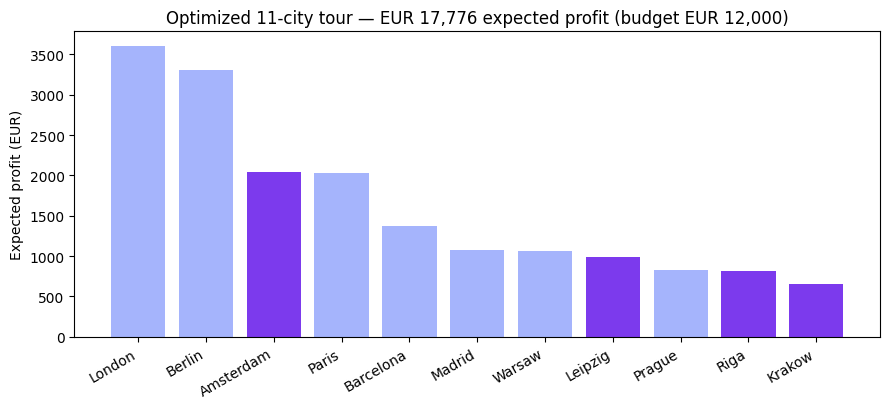

Naive 'biggest cities' tour: EUR 15,413 expected profit
Optimizer uplift: EUR 2,363 (15%) on the same budget


In [8]:
sel = pd.DataFrame(plan["cities"])
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["#7c3aed" if a > 50 else "#a5b4fc" for a in sel["arbitrage_score"]]
ax.bar(sel["city"], sel["expected_profit"], color=colors)
ax.set_ylabel("Expected profit (EUR)")
ax.set_title(f"Optimized {len(sel)}-city tour — EUR {plan['total_expected_profit_eur']:,.0f} "
             f"expected profit (budget EUR {plan['budget_eur']:,.0f})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

naive = plan["naive_big_city_comparison"]
print(f"Naive 'biggest cities' tour: EUR {naive['total_expected_profit_eur']:,.0f} expected profit")
print(f"Optimizer uplift: EUR {plan['profit_uplift_vs_naive_eur']:,.0f} "
      f"({plan['profit_uplift_vs_naive_eur']/naive['total_expected_profit_eur']:.0%}) on the same budget")

The optimizer keeps the big profitable rooms but swaps marginal capitals for underpriced secondary markets (dark bars) — cities like Leipzig and Riga where listeners-per-capita is unusually high and venues are cheap. That's the demand arbitrage: **markets big-city instinct skips.**

## Takeaways

- **Fans are a pipeline.** Scoring them like leads turns vague "engagement" into a ranked to-do list with reasons attached.
- **Expected Fan Value reallocates budget** from impressions to relationships — the top 10% of fans hold ~38% of reachable revenue.
- **Channels are not equal:** live, friend-share, and Bandcamp fans are worth multiples of editorial-playlist fans.
- **Tour where you're underpriced,** not where you're impressed — optimization beat the naive big-city route by ~15% profit on the same budget.
- **Next steps:** uplift modeling (who converts *because* of outreach vs. anyway), fan churn early-warning, and multi-artist portfolio view for small labels.